In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import math

In [2]:
# Wichtige Pfade zu Daten, Plots, etc.
path_to_data = '10.35097-1192/data/dataset/IndustrialElectricityConsumption.csv'
path_data_out = 'out'

## 📊 Datensatzbeschreibung

Dieser Datensatz enthält den **elektrischen Leistungsbedarf von 28 deutschen Unternehmen** mit einer zeitlichen Auflösung von **15 Minuten**.

🔗 **Quelle:**  
https://radar.kit.edu/radar/en/dataset/sAUaDGthjCeSYlHO

### Inhalt und Struktur
- **Zeitraum:** 2014 bis 2018  
- **Zeitliche Auflösung:** 15-Minuten-Intervalle  
- **Einheit:** Kilowatt (kW)  
- **Werte:** Mittlere Leistungswerte pro 15-Minuten-Intervall  

Die Daten wurden von Energieversorgungsunternehmen ursprünglich für **Abrechnungszwecke** erhoben.  
Die Zeitreihen wurden hinsichtlich **Inkonsistenzen bei Zeitumstellungen (Sommer-/Winterzeit)** bereinigt. Andere mögliche Fehler oder Unstimmigkeiten wurden jedoch **nicht weiter korrigiert**.

## 🔧 Datenvorverarbeitung und Umformatierung

Für das Tutorial wird der Datensatz bereits vorab strukturiert und bereinigt, damit wir uns im weiteren Verlauf auf die **Analyse der Zeitreihen** konzentrieren können.

Die ursprüngliche CSV-Datei enthält neben den Messwerten auch eine zusätzliche Label-Zeile sowie getrennte Datums- und Uhrzeitspalten. Für eine saubere Zeitreihenanalyse sind jedoch ein konsistenter Zeitstempel, numerische Werte und ein geeigneter Index erforderlich.

### Was wird hier gemacht?

1. **Einlesen der CSV-Datei**  
   Die Datei ist semikolon-getrennt (`sep=";"`).  
   `low_memory=False` verhindert unerwünschte Typ-Inferenz bei großen Dateien.

2. **Extrahieren der Label-Zeile**  
   Eine Zeile ohne Datum enthält Zusatzinformationen (z. B. Branchenzuordnung der Unternehmen `UN_1` bis `UN_28`).  
   Diese wird separat gespeichert und anschließend aus den eigentlichen Daten entfernt.

3. **Filtern der echten Messdaten**  
   Es bleiben nur Zeilen mit gültigem Datum erhalten.

4. **Erzeugen eines konsistenten Zeitstempels**  
   Datum und Uhrzeit werden kombiniert und in ein `datetime`-Format umgewandelt.  
   Das ist entscheidend für:
   - Zeitbasierte Filterung  
   - Resampling (z. B. Stunden-, Tageswerte)  
   - Zeitreihenvisualisierung  

5. **Setzen des Zeitstempel-Index**  
   Der neue `timestamp` wird als Index gesetzt und sortiert.  
   → Das ermöglicht effizientes Time-Series-Handling in Pandas.

6. **Feature Engineering für Zeitmerkmale**  
   - `weekday` (0=Montag … 6=Sonntag)  
   - `is_weekend` (Bool-Feature für Wochenend-Analysen)  

7. **Konvertieren der Verbrauchsspalten in numerische Werte**  
   Alle `UN_`-Spalten werden explizit in numerische Datentypen umgewandelt.  
   Fehlerhafte Werte werden dabei als `NaN` markiert.

---

### 🎯 Ziel der Umformatierung

Nach diesen Schritten liegt ein sauber strukturierter **Zeitreihen-DataFrame** vor, der:

- einen `DatetimeIndex` besitzt  
- ausschließlich echte Messwerte enthält  
- zusätzliche Zeitfeatures für Analysen bereitstellt  
- numerisch konsistente Verbrauchsdaten enthält  

Damit ist die Grundlage für explorative Analysen, Lastprofile, Aggregationen oder Modellierung geschaffen.

In [10]:
# 1) CSV einlesen (Semikolon-getrennt)
raw = pd.read_csv(path_to_data, sep=";", low_memory=False)

# 2) Label-Zeile extrahieren (enthält Branchenzuordnung UN_1..UN_28)
label_row = raw.loc[raw["Datum"].isna()].iloc[0]
unit_labels = label_row.filter(like="UN_").to_dict()

# 3) Nur echte Daten behalten
df = raw.loc[raw["Datum"].notna()].copy()

# 4) Datum und Uhrzeit sauber parsen
df["Datum"] = pd.to_datetime(df["Datum"], errors="coerce")
df["timestamp"] = pd.to_datetime(df["Datum"].astype(str) + " " + df["Uhrzeit"], errors="coerce")

# 5) Index setzen (für Timeseries-Handling)
df = df.set_index("timestamp").sort_index()

# 6) Wochentag aus Datum-Spalte (nicht aus Index!)
df["weekday"] = df["Datum"].dt.weekday          # 0=Mo ... 6=So
df["is_weekend"] = df["weekday"] >= 5

# 7) Uhrzeit-Feature (für Tagesprofil)
df["time"] = df.index.time

# 8) UN-Spalten numerisch machen
un_cols = [c for c in df.columns if c.startswith("UN_")]
df[un_cols] = df[un_cols].apply(pd.to_numeric, errors="coerce")

df.head()

,Datum,Uhrzeit,UN_1,UN_2,UN_3,UN_4,UN_5,UN_6,UN_7,UN_8,...,UN_22,UN_23,UN_24,UN_25,UN_26,UN_27,UN_28,weekday,is_weekend,time
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-01-01 00:15:00,2014-01-01,00:15:00,50.0,16.0,28.8,50.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,False,00:15:00
2014-01-01 00:30:00,2014-01-01,00:30:00,50.0,26.0,27.4,50.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,False,00:30:00
2014-01-01 00:45:00,2014-01-01,00:45:00,49.0,12.0,27.6,52.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,False,00:45:00
2014-01-01 01:00:00,2014-01-01,01:00:00,51.0,16.0,29.6,50.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,False,01:00:00
2014-01-01 01:15:00,2014-01-01,01:15:00,50.0,18.0,33.0,51.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,False,01:15:00


<div class="alert alert-block alert-warning">

# 🟡 Aufgabe 1: Analyse eines typischen Stromverbrauchstags

**Fragestellung:**  
Wie sieht ein typischer Stromverbrauchstag eines Industriebetriebs aus?  
Unterscheidet sich der Verbrauch am Wochenende deutlich von Werktagen?

</div>

## 🎯 Ziel der Aufgabe

In dieser Aufgabe analysieren Sie das **durchschnittliche Tageslastprofil** eines Unternehmens und untersuchen,  
ob sich das Verbrauchsverhalten zwischen **Werktagen und Wochenenden** unterscheidet.

Dabei nähern wir uns einer ersten praxisrelevanten Business-Frage:

> **„Wann wird tatsächlich produziert bzw. gearbeitet?“**


---

## 🛠️ Teil 1 – Typisches Tagesprofil

**Aufgaben:**

- [ ] Mittelwert des Verbrauchs je Uhrzeit (über alle Tage hinweg) berechnen  
- [ ] Durchschnittliches Tagesprofil visualisieren  
- [ ] Lastspitzen (Peak-Zeiten) identifizieren und im Plot markieren  

**Leitfragen zur Interpretation:**

- Zu welchen Uhrzeiten beginnt die Last deutlich anzusteigen?  
- Gibt es ein klares Produktionsfenster?  
- Ist der Verbrauch nachts konstant oder reduziert?  

In [ ]:
### Hier dein Codebereich....

---

## 🛠️ Teil 2 – Werktag vs. Wochenende

**Aufgaben:**

- [ ] Durchschnittliches Tagesprofil getrennt für Werktage und Wochenenden berechnen  
- [ ] Beide Profile vergleichen (gemeinsamer Plot empfohlen)  
- [ ] Unterschiede quantitativ und visuell bewerten  

**Leitfragen zur Interpretation:**

- Ist der Verbrauch am Wochenende signifikant geringer?  
- Läuft die Produktion durchgehend (24/7-Betrieb)?  
- Gibt es Hinweise auf Schichtbetrieb?  

---


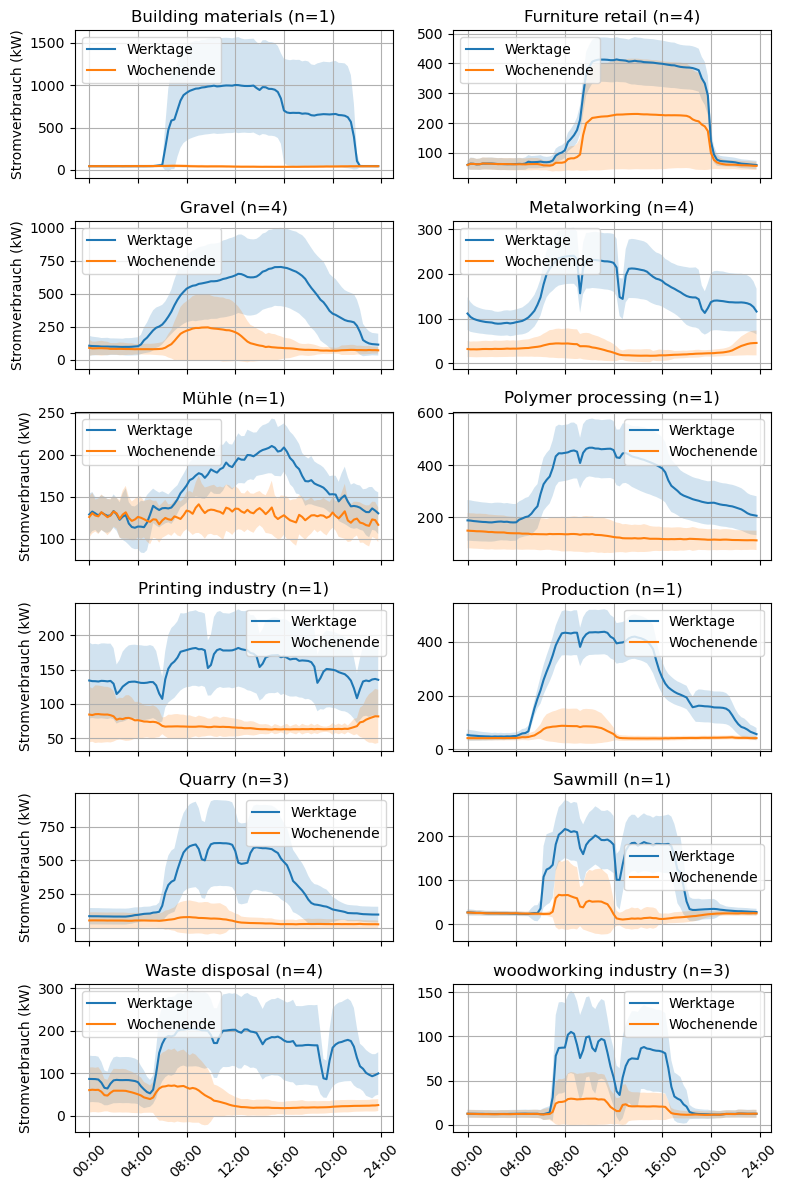

In [6]:
# --- Gruppen bauen: Branche -> UN-Spalten
industry_groups = defaultdict(list)
for unit, industry in unit_labels.items():
    if pd.notna(industry):
        industry_groups[industry].append(unit)

industries = sorted(industry_groups.keys())

# --- Hilfsfunktion: Minuten-Achse
def time_to_minutes(t):
    return t.hour * 60 + t.minute

# --- Subplot Layout
n = len(industries)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 2), sharex=True)
axes = axes.flatten()

ticks = list(range(0, 24*60+1, 240))  # alle 4 Stunden
labels = [f"{m//60:02d}:00" for m in ticks]

for i, industry in enumerate(industries):
    ax = axes[i]
    units = industry_groups[industry]

    df_ind = df[units].copy()
    df_ind["time"] = df_ind.index.time
    df_ind["is_weekend"] = df_ind.index.weekday >= 5

    # --- Werktage
    weekday = df_ind[df_ind["is_weekend"] == False]
    weekday_grouped = weekday.groupby("time")[units]

    mean_weekday = weekday_grouped.mean().mean(axis=1)
    std_weekday  = weekday_grouped.std().mean(axis=1)

    # --- Wochenende
    weekend = df_ind[df_ind["is_weekend"] == True]
    weekend_grouped = weekend.groupby("time")[units]

    mean_weekend = weekend_grouped.mean().mean(axis=1)
    std_weekend  = weekend_grouped.std().mean(axis=1)

    # --- x-Achse (Minuten)
    x = [time_to_minutes(t) for t in mean_weekday.index]

    # --- Plot Werktage + Band
    ax.plot(x, mean_weekday.values, label="Werktage")
    ax.fill_between(
        x,
        mean_weekday.values - std_weekday.values,
        mean_weekday.values + std_weekday.values,
        alpha=0.2
    )

    # --- Plot Wochenende + Band
    ax.plot(x, mean_weekend.values, label="Wochenende")
    ax.fill_between(
        x,
        mean_weekend.values - std_weekend.values,
        mean_weekend.values + std_weekend.values,
        alpha=0.2
    )

    ax.set_title(f"{industry} (n={len(units)})")
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=45)
    ax.grid(True)
    #ax.set_ylim(0,1500) #selbe Skala

    if i % cols == 0:
        ax.set_ylabel("Stromverbrauch (kW)")

    ax.legend()

# Falls Subplots leer bleiben, entfernen
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Analyse für Branche: Metalworking (n=4)


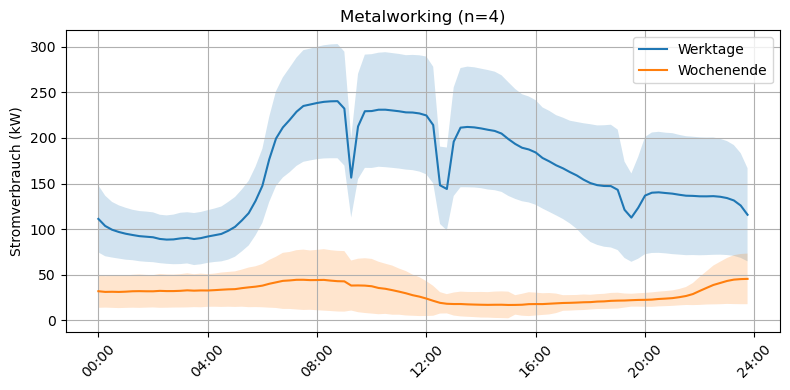

In [7]:
# --------------------------------------------------
# 1) Branche auswählen (manuell setzen)
# --------------------------------------------------
selected_industry = "Metalworking"   # <-- hier Branche anpassen

# Zugehörige UN-Spalten
units = [unit for unit, industry in unit_labels.items()
         if industry == selected_industry]

print(f"Analyse für Branche: {selected_industry} (n={len(units)})")

# --------------------------------------------------
# 2) Daten vorbereiten
# --------------------------------------------------
df_ind = df[units].copy()
df_ind["time"] = df_ind.index.time
df_ind["is_weekend"] = df_ind.index.weekday >= 5


# --------------------------------------------------
# 3) Werktage
# --------------------------------------------------
weekday = df_ind[df_ind["is_weekend"] == False]
weekday_grouped = weekday.groupby("time")[units]

mean_weekday = weekday_grouped.mean().mean(axis=1)
std_weekday  = weekday_grouped.std().mean(axis=1)


# --------------------------------------------------
# 4) Wochenende
# --------------------------------------------------
weekend = df_ind[df_ind["is_weekend"] == True]
weekend_grouped = weekend.groupby("time")[units]

mean_weekend = weekend_grouped.mean().mean(axis=1)
std_weekend  = weekend_grouped.std().mean(axis=1)


# --------------------------------------------------
# 5) Hilfsfunktion für Minuten-Achse
# --------------------------------------------------
def time_to_minutes(t):
    return t.hour * 60 + t.minute

x = [time_to_minutes(t) for t in mean_weekday.index]

ticks = list(range(0, 24*60+1, 240))  # alle 4 Stunden
labels = [f"{m//60:02d}:00" for m in ticks]


# --------------------------------------------------
# 6) Plot
# --------------------------------------------------
plt.figure(figsize=(8,4))

# Werktage
plt.plot(x, mean_weekday.values, label="Werktage")
plt.fill_between(
    x,
    mean_weekday.values - std_weekday.values,
    mean_weekday.values + std_weekday.values,
    alpha=0.2
)

# Wochenende
plt.plot(x, mean_weekend.values, label="Wochenende")
plt.fill_between(
    x,
    mean_weekend.values - std_weekend.values,
    mean_weekend.values + std_weekend.values,
    alpha=0.2
)

plt.title(f"{selected_industry} (n={len(units)})")
plt.xticks(ticks, labels, rotation=45)
plt.ylabel("Stromverbrauch (kW)")
plt.grid(True)
plt.legend()

plt.tight_layout()
#plt.savefig("example_plot_exercise1.png")
plt.show()

## 💡 Tipps

### Teil 1 – Typisches Tagesprofil (Werktage / allgemein)

- **Tipp 1: Nutze den Zeitstempel-Index konsequent für das Tagesprofil.**  
  Gruppiere nach `df.index.time`, damit wirklich nur die *Uhrzeit innerhalb des Tages* betrachtet wird (00:00–23:45), unabhängig vom Datum.

- **Tipp 2: Markiere Peaks nicht nur visuell, sondern auch rechnerisch.**  
  Ein einfacher Start ist `idxmax()` auf dem mittleren Tagesprofil (z. B. pro Branche), um die Peak-Uhrzeit automatisch zu bestimmen und im Plot zu annotieren.


### Teil 2 – Werktag vs. Wochenende

- **Tipp 1: Vergleiche die Profile im selben Plot und achte auf die Skala.**  
  Unterschiedliche y-Skalen können den Eindruck verzerren. Optional eine feste y-Achse (`ax.set_ylim(...)`) nutzen, wenn du mehrere Branchen vergleichst.

- **Tipp 2: Zeige die Streuung als „Unsicherheitsband“.**  
  Ein Band (z. B. Mittelwert ± Standardabweichung) hilft zu erkennen, ob Unterschiede zwischen Werktagen und Wochenende *stabil* sind oder stark schwanken.

<div class="alert alert-block alert-warning">

# 🟡 Aufgabe 2: Wie hoch ist der Stromverbrauch nachts?

**Fragestellung:**  
Wie hoch ist der Stromverbrauch zwischen 00:00 und 04:00 Uhr,  
wenn der Betrieb eigentlich „aus“ sein sollte?

</div>

## 🎯 Ziel der Aufgabe

In dieser Analyse untersuchen wir die sogenannte **Grundlast** eines Unternehmens.  
Die Grundlast beschreibt den Stromverbrauch in Zeiten, in denen keine aktive Produktion erwartet wird.

Dies ist ein klassischer **Nachhaltigkeits- und Effizienz-Use-Case**:
> Wie viel Energie wird verbraucht, obwohl eigentlich keine Wertschöpfung stattfindet?

---

## 🛠️ To Do

- [ ] Durchschnittlichen Verbrauch zwischen **00:00–04:00 Uhr** berechnen  
- [ ] Anteil der Nachtlast am durchschnittlichen Gesamtverbrauch bestimmen  
- [ ] Mögliches Einsparpotenzial abschätzen  
- [ ] Ergebnisse pro Branche vergleichen  

---

## 🌱 Business-Perspektive

Ein hoher Nachtanteil kann hinweisen auf:

- Dauerbetrieb (24/7-Produktion)
- Standby-Verluste
- ineffiziente Anlagen
- nicht abgeschaltete Infrastruktur

Ein realistisches Szenario:  
> Was würde passieren, wenn der Nachtverbrauch auf z. B. 20 % des Tagesdurchschnitts gesenkt werden könnte?

Damit wird aus einer reinen Datenanalyse eine konkrete **Energieeffizienz-Strategie**.

In [ ]:
### Hier dein Codebereich....

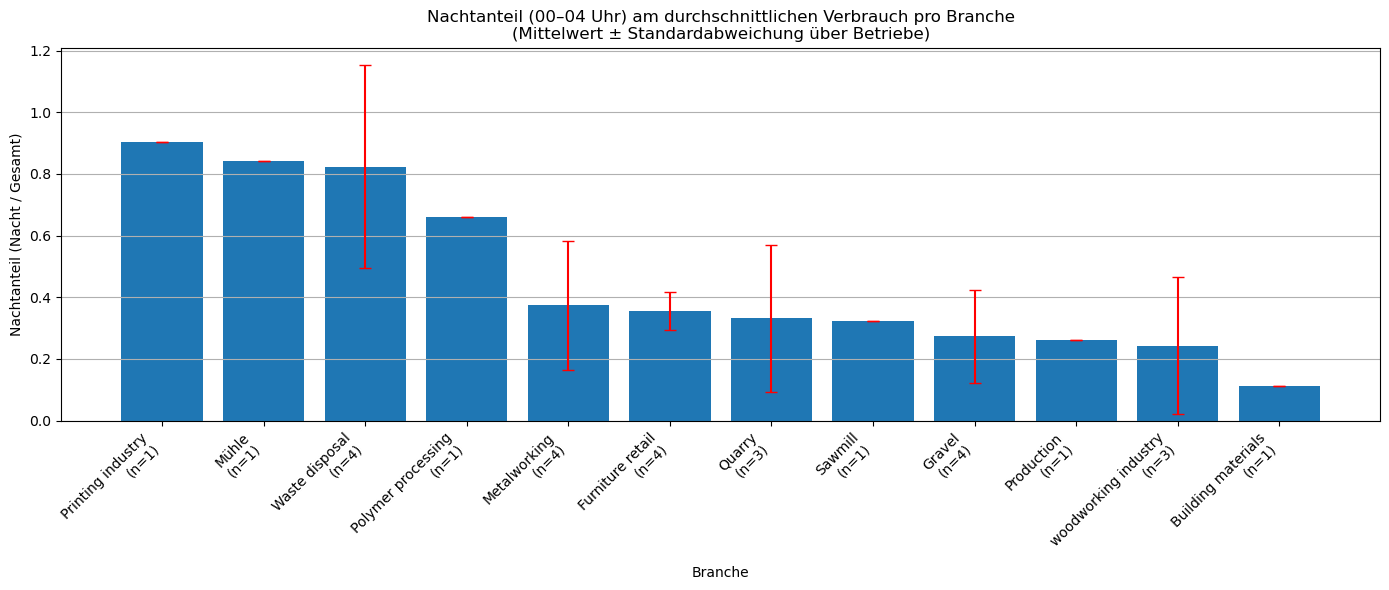

In [12]:
# --- 1) Gruppen: Branche -> UN-Spalten
groups = (
    pd.Series(unit_labels)
      .dropna()
      .groupby(lambda k: unit_labels[k])
      .apply(lambda s: list(s.index))
      .to_dict()
)

un_cols = [c for c in df.columns if c.startswith("UN_")]
# nur Units behalten, die wirklich im df sind
groups = {ind: [u for u in units if u in un_cols] for ind, units in groups.items()}
groups = {ind: units for ind, units in groups.items() if len(units) > 0}

# --- 2) Nachtfenster (00:00–03:59)
night_mask = df["time"].apply(lambda t: (t.hour >= 0) and (t.hour < 4))

# pro Unit: durchschnitt Nacht, duschschnitt Gesamt, Anteil Nacht
night_mean_per_unit = df.loc[night_mask, un_cols].mean(skipna=True)
overall_mean_per_unit = df[un_cols].mean(skipna=True)
night_ratio_per_unit = night_mean_per_unit / overall_mean_per_unit

per_unit = pd.DataFrame({
    "industry": pd.Series(unit_labels),
    "night_mean_0_4": night_mean_per_unit,
    "overall_mean": overall_mean_per_unit,
    "night_ratio": night_ratio_per_unit
}).dropna(subset=["industry"])

# --- 3) Aggregation pro Branche
# (Mittel/Median/Std über Betriebe derselben Branche)
by_industry = (
    per_unit.groupby("industry")
    .agg(
        n_units=("night_ratio", "size"),
        night_mean_0_4_mean=("night_mean_0_4", "mean"),
        night_mean_0_4_std=("night_mean_0_4", "std"),
        night_ratio_mean=("night_ratio", "mean"),
        night_ratio_median=("night_ratio", "median"),
        night_ratio_std=("night_ratio", "std"),
    )
    .sort_values("night_ratio_mean", ascending=False)
)

# --- 4) (Optional) Einsparpotenzial-Schätzer
# Ziel: nachts nur noch target_ratio * Tagesdurchschnitt (z.B. 0.2 = 20%)
target_ratio = 0.20
per_unit["target_night_mean"] = per_unit["overall_mean"] * target_ratio
per_unit["night_saving_abs"] = (per_unit["night_mean_0_4"] - per_unit["target_night_mean"]).clip(lower=0)

saving_by_industry = (
    per_unit.groupby("industry")
    .agg(
        night_saving_abs_mean=("night_saving_abs", "mean"),
        night_saving_abs_sum=("night_saving_abs", "sum"),
    )
)

# alles zusammenführen
by_industry = by_industry.join(saving_by_industry)

plot_df = by_industry.copy()

# NaNs bei std (z.B. wenn n=1) auf 0 setzen, sonst bricht errorbar
plot_df["night_ratio_std"] = plot_df["night_ratio_std"].fillna(0)

x = np.arange(len(plot_df))

plt.figure(figsize=(14, 6))
plt.bar(x, plot_df["night_ratio_mean"].values)
plt.errorbar(
    x,
    plot_df["night_ratio_mean"].values,
    yerr=plot_df["night_ratio_std"].values,
    fmt="none",
    capsize=4, color="red"
)

plt.title("Nachtanteil (00–04 Uhr) am durchschnittlichen Verbrauch pro Branche\n(Mittelwert ± Standardabweichung über Betriebe)")
plt.xlabel("Branche")
plt.ylabel("Nachtanteil (Nacht / Gesamt)")

# Achsenbeschriftung inkl. n
labels = [f"{ind}\n(n={int(n)})" for ind, n in zip(plot_df.index, plot_df["n_units"])]
plt.xticks(x, labels, rotation=45, ha="right")

plt.grid(True, axis="y")
plt.tight_layout()
#plt.savefig("Example_Plots/example_plot_exercise2.png")
plt.show()

In [13]:
display(
    (by_industry.assign(
        night_ratio_mean_pct=by_industry["night_ratio_mean"] * 100,
        night_ratio_std_pct=by_industry["night_ratio_std"] * 100
    )[["n_units","night_ratio_mean_pct","night_ratio_std_pct",
       "night_mean_0_4_mean","night_mean_0_4_std",
       "night_saving_abs_mean","night_saving_abs_sum"]]
     .sort_values("night_ratio_mean_pct", ascending=False))
)


,n_units,night_ratio_mean_pct,night_ratio_std_pct,night_mean_0_4_mean,night_mean_0_4_std,night_saving_abs_mean,night_saving_abs_sum
industry,,,,,,,
Printing industry,1,90.503559,NaN,116.120137,NaN,90.459237,90.459237
Mühle,1,84.193779,NaN,126.457789,NaN,96.418090,96.418090
Waste disposal,4,82.313127,32.867959,73.941755,59.170461,50.556222,202.224889
Polymer processing,1,65.929566,NaN,172.013953,NaN,119.832826,119.832826
Metalworking,4,37.391077,21.006897,76.181192,149.422879,51.939712,207.758847
Furniture retail,4,35.620797,6.250603,62.704232,80.676294,24.233305,96.933218
Quarry,3,33.276335,23.848645,75.547603,92.401386,41.224003,123.672008
Sawmill,1,32.429812,NaN,25.501507,NaN,9.774307,9.774307
Gravel,4,27.324129,14.969602,95.594092,93.217446,38.663166,154.652664


---

## 💡 Tipps

### Tipp 1: Nachtverbrauch ins Verhältnis setzen  
Ein absoluter kW-Wert ist wenig aussagekräftig.  
Interessanter ist der **relative Anteil**:

$$
\text{Nachtanteil} = 
\frac{\text{Durchschnitt Nacht (0--4 Uhr)}}{\text{Durchschnitt Gesamt}}
$$

So werden unterschiedlich große Betriebe vergleichbar.

### Tipp 2: Streuung beachten  
Nicht nur den Mittelwert pro Branche betrachten –  
die **Standardabweichung** zeigt, wie stark sich Betriebe innerhalb einer Branche unterscheiden.


<div class="alert alert-block alert-warning">

# 🟡 Aufgabe 3: Wie stark könnte das Unternehmen seine Lastspitzen senken, ohne Produktion abzuschalten?

</div>

## 🎯 Ziel der Aufgabe

Untersuchen Sie, in welchem Umfang Lastspitzen („Peaks“) reduziert werden könnten,  
ohne die eigentliche Produktionslast wesentlich zu beeinträchtigen.

Dabei geht es nicht darum, den Verbrauch pauschal zu senken,  
sondern gezielt **kurzzeitige Überhöhungen** zu identifizieren und zu glätten.


## 🛠️ To Do

- [ ] Höchste Peaks je Betrieb identifizieren  
- [ ] Eine sinnvolle „Cap“-Strategie definieren  
- [ ] Potenzielle Reduktion in kW berechnen  
- [ ] Ergebnisse interpretieren  

---

## 🔎 Methodische Freiheit

Es gibt mehrere sinnvolle Wege, sich der Frage zu nähern.  
Zum Beispiel:

**Variante A (einfach):**
- Maximalwert bestimmen  
- z. B. auf 90 % des Peaks begrenzen  
- Differenz berechnen  

**Variante B (robuster, empfohlen):**
- 95%-Perzentil (P95) berechnen  
- Peak mit P95 vergleichen  
- Last oberhalb von P95 als „Shaving-Potenzial“ interpretieren  

Beide Ansätze sind zulässig –  
wichtig ist eine **nachvollziehbare Begründung** der gewählten Methode.

## 💡 Leitfragen zur Interpretation

- Sind die Peaks seltene Ausreißer oder strukturell notwendig?  
- Wie groß ist das realistische Reduktionspotenzial?  
- Wäre dafür ein Speicher ausreichend – oder bräuchte es Prozessanpassungen?  
- Welche Branchen wirken besonders „spitz“ im Lastprofil?

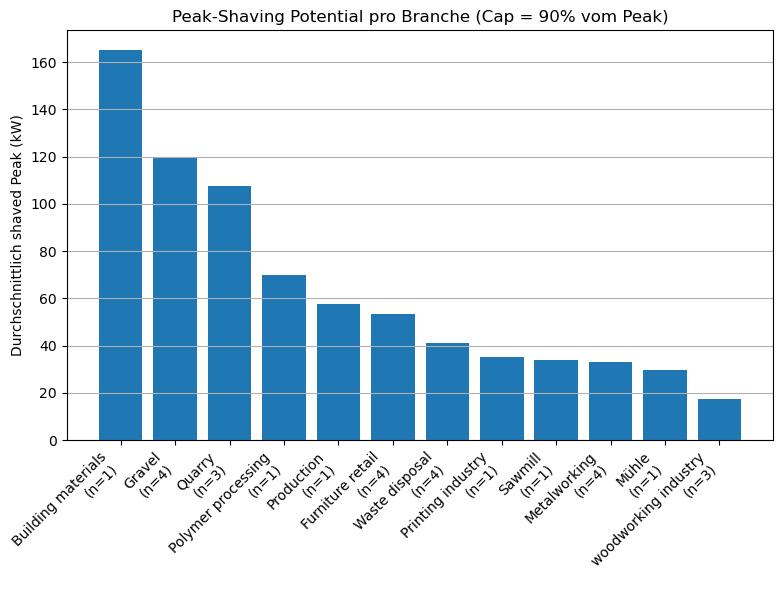

,peak_kw,cap_kw,max_shaved_kw,total_shaved_kw_sum,relative_peak_reduction,industry,cost_saving_est_eur_year
UN_21,1756.00,1580.400,175.600,5657.200,0.1,Gravel,17560.0
UN_5,1652.00,1486.800,165.200,61273.600,0.1,Building materials,16520.0
UN_20,1633.84,1470.456,163.384,14017.448,0.1,Quarry,16338.4
UN_16,1585.00,1426.500,158.500,15192.000,0.1,Furniture retail,15850.0
UN_11,1508.00,1357.200,150.800,3397.200,0.1,Gravel,15080.0
UN_25,1242.09,1117.881,124.209,4653.772,0.1,Quarry,12420.9
UN_23,1186.00,1067.400,118.600,3904.400,0.1,Gravel,11860.0
UN_9,1168.00,1051.200,116.800,5188.920,0.1,Metalworking,11680.0
UN_4,908.00,817.200,90.800,3698.800,0.1,Waste disposal,9080.0
UN_26,697.20,627.480,69.720,534.560,0.1,Polymer processing,6972.0


In [15]:
### Variante A
un_cols = [c for c in df.columns if c.startswith("UN_")]

peak_per_unit = df[un_cols].max()
peak_per_unit.sort_values(ascending=False).head(10)

cap_factor = 0.90 # max.90%

caps = peak_per_unit * cap_factor
df_capped = df[un_cols].clip(upper=caps, axis=1)

savings_kw = df[un_cols] - df_capped

total_saving_kw = savings_kw.sum()
total_saving_kw.sort_values(ascending=False).head(10)

max_shaved_kw = savings_kw.max()
max_shaved_kw.sort_values(ascending=False).head(10)

result_units = pd.DataFrame({
    "peak_kw": peak_per_unit,
    "cap_kw": caps,
    "max_shaved_kw": max_shaved_kw,
    "total_shaved_kw_sum": total_saving_kw
})

result_units["relative_peak_reduction"] = result_units["max_shaved_kw"] / result_units["peak_kw"]

result_units.sort_values("max_shaved_kw", ascending=False).head(10)

result_units["industry"] = pd.Series(unit_labels)

result_industry = (
    result_units.dropna(subset=["industry"])
    .groupby("industry")
    .agg(
        n_units=("peak_kw", "size"),
        peak_mean=("peak_kw", "mean"),
        cap_mean=("cap_kw", "mean"),
        max_shaved_mean=("max_shaved_kw", "mean"),
        total_shaved_sum=("total_shaved_kw_sum", "sum"),
        rel_reduction_mean=("relative_peak_reduction", "mean")
    )
    .sort_values("max_shaved_mean", ascending=False)
)

result_industry

plot_df = result_industry.copy()
x = np.arange(len(plot_df))

plt.figure(figsize=(8,6))
plt.bar(x, plot_df["max_shaved_mean"].values)

labels = [f"{ind}\n(n={int(n)})" for ind, n in zip(plot_df.index, plot_df["n_units"])]
plt.xticks(x, labels, rotation=45, ha="right")

plt.title(f"Peak-Shaving Potential pro Branche (Cap = {int(cap_factor*100)}% vom Peak)")
plt.ylabel("Durchschnittlich shaved Peak (kW)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

### Könnte einfach beliebig schätzen wie viel "Geld eingespart wird"
leistungspreis = 100  # €/kW/Jahr (eine Beispielzahl einfach)

result_units["cost_saving_est_eur_year"] = result_units["max_shaved_kw"] * leistungspreis
result_units.sort_values("cost_saving_est_eur_year", ascending=False).head(10)

Die vorherige Methode ist ungeeignet, weil ein Cap von z.B. 90% des Peaks mathematisch immer eine maximale Reduktion von genau 10% erzwingt und dadurch das Ergebnis hauptsächlich davon abhängt, welche Branche einfach den höchsten absoluten Peak hat (größter Betrieb), statt zu zeigen, ob die Lastspitzen echte kurze Ausreißer sind, die man ohne Produktionsstopp realistisch glätten kann.

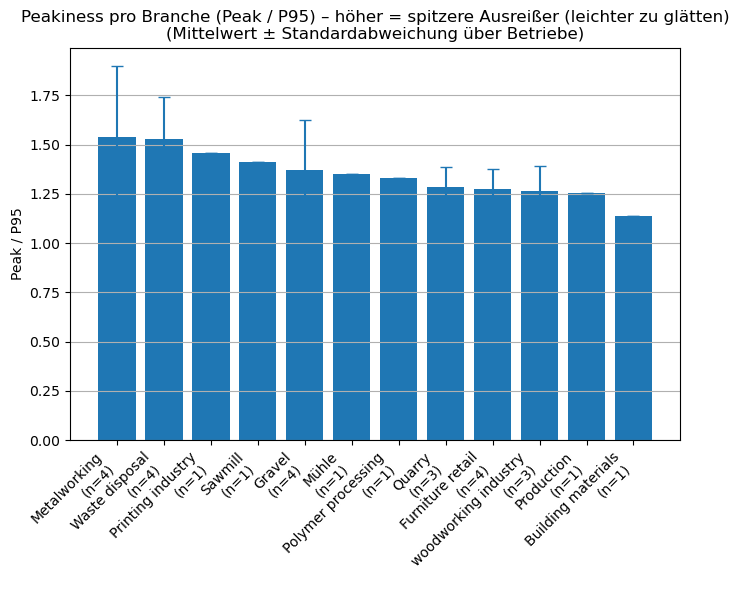

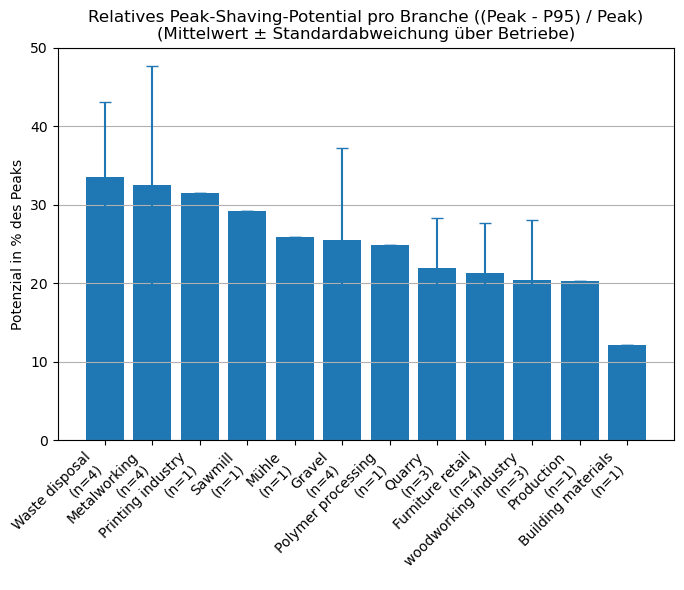

,n_units,peak_mean,p95_mean,peakiness_ratio_mean,peakiness_ratio_std,shave_potential_rel_mean,shave_potential_rel_std
industry,,,,,,,
Metalworking,4,331.500000,265.175000,1.541194,0.356259,0.325025,0.151253
Waste disposal,4,409.500000,296.650000,1.528274,0.212987,0.335719,0.095385
Printing industry,1,352.800000,241.600000,1.460265,0.000000,0.315193,NaN
Sawmill,1,337.360000,239.044000,1.411288,0.000000,0.291428,NaN
Gravel,4,1194.100000,936.300000,1.372193,0.251453,0.255112,0.117588
Mühle,1,298.184000,220.936000,1.349640,0.000000,0.259062,NaN
Polymer processing,1,697.200000,523.600000,1.331551,0.000000,0.248996,NaN
Quarry,3,1074.553333,857.015000,1.285817,0.100526,0.218967,0.063657
Furniture retail,4,534.825000,448.945000,1.277339,0.101377,0.213385,0.062942


In [16]:
### Variante B
un_cols = [c for c in df.columns if c.startswith("UN_")]

# --- Peakiness pro Betrieb (robust): Peak vs. P95
p95_per_unit  = df[un_cols].quantile(0.95)
peak_per_unit = df[un_cols].max()

peakiness_ratio = peak_per_unit / p95_per_unit                      # >1 => "spikier"
shave_potential_rel = (peak_per_unit - p95_per_unit) / peak_per_unit # Anteil des Peaks über P95

result_units_peakiness = pd.DataFrame({
    "industry": pd.Series(unit_labels),
    "p95_kw": p95_per_unit,
    "peak_kw": peak_per_unit,
    "peakiness_ratio": peakiness_ratio,
    "shave_potential_rel": shave_potential_rel
}).dropna(subset=["industry"])

# --- pro Branche aggregieren
result_industry_peakiness = (
    result_units_peakiness
    .groupby("industry")
    .agg(
        n_units=("peak_kw", "size"),
        peak_mean=("peak_kw", "mean"),
        p95_mean=("p95_kw", "mean"),
        peakiness_ratio_mean=("peakiness_ratio", "mean"),
        peakiness_ratio_std=("peakiness_ratio", "std"),
        shave_potential_rel_mean=("shave_potential_rel", "mean"),
        shave_potential_rel_std=("shave_potential_rel", "std"),
    )
)

# Sortierung: "spikiness" hoch = tendenziell leichteres Peak Shaving
plot_df = result_industry_peakiness.sort_values("peakiness_ratio_mean", ascending=False).copy()
plot_df["peakiness_ratio_std"] = plot_df["peakiness_ratio_std"].fillna(0)

# --- Plot: Peakiness-Ratio pro Branche (Mean +- Std)
x = np.arange(len(plot_df))
plt.figure(figsize=(7, 6))
plt.bar(x, plot_df["peakiness_ratio_mean"].values)
plt.errorbar(
    x,
    plot_df["peakiness_ratio_mean"].values,
    yerr=plot_df["peakiness_ratio_std"].values,
    fmt="none",
    capsize=4
)

labels = [f"{ind}\n(n={int(n)})" for ind, n in zip(plot_df.index, plot_df["n_units"])]
plt.xticks(x, labels, rotation=45, ha="right")
plt.title("Peakiness pro Branche (Peak / P95) – höher = spitzere Ausreißer (leichter zu glätten)\n(Mittelwert ± Standardabweichung über Betriebe)")
plt.ylabel("Peak / P95")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# --- Plot: Relatives Shaving-Potential (Peak - P95) / Peak in %
plot_df2 = result_industry_peakiness.sort_values("shave_potential_rel_mean", ascending=False).copy()
plot_df2["shave_potential_rel_std"] = plot_df2["shave_potential_rel_std"].fillna(0)

x2 = np.arange(len(plot_df2))
plt.figure(figsize=(7, 6))
plt.bar(x2, (plot_df2["shave_potential_rel_mean"].values * 100))
plt.errorbar(
    x2,
    (plot_df2["shave_potential_rel_mean"].values * 100),
    yerr=(plot_df2["shave_potential_rel_std"].values * 100),
    fmt="none",
    capsize=4
)

labels2 = [f"{ind}\n(n={int(n)})" for ind, n in zip(plot_df2.index, plot_df2["n_units"])]
plt.xticks(x2, labels2, rotation=45, ha="right")
plt.title("Relatives Peak-Shaving-Potential pro Branche ((Peak - P95) / Peak)\n(Mittelwert ± Standardabweichung über Betriebe)")
plt.ylabel("Potenzial in % des Peaks")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# Tabelle anzeigen
display(plot_df[[
    "n_units",
    "peak_mean",
    "p95_mean",
    "peakiness_ratio_mean",
    "peakiness_ratio_std",
    "shave_potential_rel_mean",
    "shave_potential_rel_std"
]])


Das Unternehmen könnte je nach Branche ca. 20–35% der Lastspitzen reduzieren, ohne Produktion komplett abzuschalten, da die Peaks häufig Ausreißer über dem 95%-Quantil sind.
Besonders in Waste disposal, Metalworking und Printing industry sind Peaks deutlich stärker ausgeprägt (Peak/P95 ≈ 1.5), was auf kurzfristige, steuerbare Lasten hinweist.

## 💡 Tipps für Variante A (Fixes Cap, z. B. 90 % des Peaks)

### Tipp 1: Cap sauber definieren

Bestimmen Sie zunächst den maximalen Leistungswert:

$$
\text{Peak} = \max(P_t)
$$

Definieren Sie dann ein Cap, z. B.:

$$
\text{Cap} = 0{,}9 \cdot \text{Peak}
$$

Alle Werte oberhalb dieses Caps werden in der Simulation auf das Cap begrenzt.

### Tipp 2: Einsparung korrekt berechnen

Die potenzielle Reduktion ergibt sich nur aus den Zeitpunkten,  
an denen der Verbrauch über dem Cap liegt:

$$
\text{Reduktion}_t = \max(0, P_t - \text{Cap})
$$

Wichtig:  
Nicht einfach pauschal 10 % vom Gesamtverbrauch abziehen —  
es geht nur um die „abgeschnittenen“ Spitzen.

### Tipp 3: Häufigkeit berücksichtigen

Prüfen Sie zusätzlich:

- Wie oft tritt der Peak auf?
- Wie viele Zeitintervalle liegen über dem Cap?
- Handelt es sich um seltene Ausreißer oder häufige Überschreitungen?

Das beeinflusst die Realisierbarkeit des Peak-Shavings erheblich.

### ⚖️ Reflexionsfrage

Ist ein fixes 90 %-Cap realistisch?

- Wenn der Peak nur einmal im Jahr auftritt → evtl. sehr hohes theoretisches Potenzial  
- Wenn viele Werte nahe am Maximum liegen → strukturelle Last, schwer zu reduzieren

## 💡 Tipps für Variante B (robust: Peak vs. P95)

### Tipp 1: Warum P95 statt „Cap = 90 % Peak“?
Der **Maximalwert** kann ein einzelner Ausreißer sein (Messfehler, kurzer Anfahrpeak, Sonderereignis).  
Das **95%-Perzentil (P95)** beschreibt dagegen ein „typisch hohes“ Lastniveau.

→ Die Differenz **Peak − P95** ist eine plausible Näherung für das *glättbare* Peak-Stück.

### Tipp 2: „Peakiness“ richtig interpretieren
$$
\text{Peakiness}=\frac{\text{Peak}}{\text{P95}}
$$

- **≈ 1.0 – 1.1:** kaum Ausreißer → Last ist eher „plateauartig“ (schwer zu glätten)
- **> 1.2:** deutliche Ausreißer → Peaks sind eher spitz (tendenziell leichter zu glätten)
- **sehr hoch:** kann auch auf Datenfehler / seltene Extremwerte hindeuten → Plausibilitätscheck lohnt sich

### Tipp 3: Shaving-Potential als Prozentwert ist gut vergleichbar
$$
\text{Shaving-Potenzial (rel.)}=\frac{\text{Peak}-\text{P95}}{\text{Peak}}
$$

Dieser Wert ist dimensionslos und macht Betriebe/Branchen unterschiedlicher Größe vergleichbar.

**Merke:** Ein hoher Prozentwert bedeutet nicht automatisch hohe kW-Einsparung –  
deshalb (optional) auch immer den absoluten Wert betrachten:  
$$
\text{Shaving (kW)}=\text{Peak}-\text{P95}
$$


### Tipp 4: Streuung ist Teil der Aussage
Wenn du nach Branchen aggregierst:
- Mittelwert zeigt „typisches Verhalten“
- **Standardabweichung** zeigt, ob eine Branche homogen ist oder ob einzelne Betriebe stark abweichen

Wenn `n=1`, ist `std` oft `NaN` → das kann man (wie im Code) zu 0 setzen, damit Plots nicht crashen.



### Tipp 5: Validierungsidee (optional, aber sehr lehrreich)
Wähle **eine Branche oder ein Unternehmen** mit hoher Peakiness und plotte die Zeitreihe für einige Tage.  
So sieht man sofort, ob Peaks:
- sehr kurz (gut glättbar, z. B. Batterie/Steuerung)
- oder länger (eher strukturell, schwer „ohne Produktionsänderung“)

### ⚖️ Reflexionsfrage
Wenn Peaks spitz sind (hoch Peak/P95), welche Maßnahmen wären plausibel?

- Kurzzeitige Glättung: Speicher, Lastmanagement, Startzeiten verschieben  
- Falls Peaks lang sind: Prozessänderungen oder echte Lastreduktion notwendig

<div class="alert alert-block alert-warning">

# 🟡 Frage 4: Welche Prozesse könnte man in emissionsärmere Zeiten verschieben?

</div>

## 🎯 Ziel der Frage

Diskutieren Sie, welche betrieblichen Prozesse zeitlich flexibel sind  
und daher in Zeitfenster mit niedrigerem CO₂-Faktor des Strommixes verschoben werden könnten.

Es geht nicht um technische Details, sondern um eine **konzeptionelle Bewertung von Flexibilitätspotenzialen**.


---

## 💡 Mögliche Ansatzpunkte

Typischerweise verschiebbare Prozesse sind:

### 🏭 1. Nicht-kritische Produktionsschritte
- Vorproduktion / Zwischenfertigung
- Batch-Prozesse mit Pufferlager
- Reinigungs- oder Rüstvorgänge

### 🔥 2. Energieintensive Nebenprozesse
- Druckluft-Erzeugung
- Kälte- oder Wärmeerzeugung
- industrielle Öfen mit thermischer Trägheit
- Wasseraufbereitung

### ⚡ 3. Speicherbare Prozesse
- Batteriespeicher laden
- Warmwasser- oder Dampfspeicher füllen
- Kältespeicher vorladen

### 🚛 4. Unterstützende Infrastruktur
- Elektrofahrzeuge laden
- interne Logistiksysteme
- nicht zeitkritische IT-Lasten

---

## 🔎 Leitfragen zur Diskussion

- Welche Prozesse müssen synchron mit der Produktion laufen?
- Wo gibt es Puffer (Lager, Speicher, Zwischenprodukte)?
- Welche Prozesse haben thermische oder elektrische Trägheit?
- Gibt es regulatorische oder organisatorische Einschränkungen?

---

## 🌱 Systemperspektive

Emissionsärmere Zeiten treten häufig auf bei:

- hoher erneuerbarer Einspeisung (Wind-/Solarspitzen)
- geringer Gesamtnachfrage
- bestimmten Tageszeiten (z. B. mittags bei PV-Überschuss)

Die strategische Frage lautet:

> Wie kann das Unternehmen von einem zunehmend erneuerbaren Stromsystem profitieren?


Basierend auf den Plots (Peak/P95 und relatives Peak-Shaving-Potenzial) zeigen insbesondere die Branchen **Waste disposal**, **Metalworking** und **Printing industry** hohe Werte, was darauf hindeutet, dass dort häufig **kurzzeitige Lastspitzen** auftreten, die sich relativ gut zeitlich verschieben lassen. 

Daher könnten in diesen Branchen vor allem **steuerbare, nicht kontinuierliche Prozesse** in emissionsärmere Zeiten verlagert werden, z.B. **Druckluft-Erzeugung (Kompressoren)**, **Pumpen und Fördertechnik**, **kurze Maschinenläufe wie Pressen, Schreddern oder Zerkleinern**, sowie **Batch-Prozesse wie Mischen, Mahlen oder Aufheizen/Trocknen**. 

Branchen mit geringerem Peak-Shaving-Potenzial wie **Building materials** deuten hingegen eher auf **konstante Grundlast** und kontinuierliche Prozesse hin, die sich deutlich schwieriger ohne Produktionsunterbrechung verschieben lassen.


<div class="alert alert-block alert-warning">

# 🟡 Frage 5: Was sagen die Daten – und was sagen sie nicht?

</div>

## 🎯 Ziel der Aufgabe

Nutzen Sie die bisherigen Analysen als Ausgangspunkt und  
untersuchen Sie selbstständig weitere interessante Fragestellungen.

Diese Aufgabe ist bewusst offen gestaltet.

---

## 🛠️ Mögliche Richtungen (Inspiration)

Sie könnten zum Beispiel untersuchen:

- Gibt es saisonale Muster (Sommer vs. Winter)?
- Wie unterscheiden sich einzelne Betriebe innerhalb einer Branche?
- Gibt es auffällige Ausreißer oder ungewöhnliche Zeiträume?
- Verändert sich das Lastprofil über die Jahre?
- Gibt es Hinweise auf Schichtbetrieb?
- Wie stark schwankt die Last innerhalb eines Tages?

Sie dürfen eigene Hypothesen formulieren und testen. (Dabei auch gerne Machine-Learning Algortihmen verwenden 😊)

---

## 🔎 Ebenso wichtig: Was sagen die Daten NICHT?

Reflektieren Sie auch kritisch:

- Es gibt keine Produktionsmengen → Effizienz nicht direkt bewertbar  
- Keine Informationen zu CO₂-Intensität des Strommixes  
- Keine Preisinformationen  
- Keine Prozessinformationen  
- Keine Unterscheidung zwischen Grundlast und Produktionslast  

Welche zusätzlichen Daten wären notwendig, um fundierte betriebliche Entscheidungen zu treffen?

---

## 📊 Erwartung

Es gibt keine „richtige“ Lösung.  
Bewertet werden:

- Qualität der Fragestellung  
- Saubere Methodik  
- Plausible Interpretation  
- Kritische Reflexion der Datengrenzen  

---

## 🌱 Ziel der Übung

Datenanalyse bedeutet nicht nur Rechnen,  
sondern auch:

- sinnvolle Fragen stellen  
- Annahmen hinterfragen  
- Unsicherheiten erkennen  
- Grenzen der Aussagekraft verstehen

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

industry = "Waste disposal"
units = groups[industry]

# Branche aggregieren
tmp = df[units].mean(axis=1).to_frame("load")
tmp["date"] = pd.to_datetime(tmp.index.date)
tmp["time"] = tmp.index.time

# nur Werktage
tmp = tmp[tmp["date"].dt.weekday < 5]

# Tagesmatrix: Zeilen=Datum, Spalten=Uhrzeit
daily_matrix = tmp.pivot_table(index="date", columns="time", values="load", aggfunc="mean")

# fehlende Werte auffüllen (z.B. falls Daten fehlen)
daily_matrix = daily_matrix.ffill(axis=1).bfill(axis=1)
print(daily_matrix)

time        00:00:00  00:15:00  00:30:00  00:45:00  01:00:00  01:15:00  \
date                                                                     
2014-01-01     36.20     36.20     38.35     35.15     36.65     38.00   
2014-01-02     33.70     35.10     38.25     33.60     33.20     36.05   
2014-01-03     50.05     48.45     49.00     49.05     50.60     47.10   
2014-01-06     41.55     40.45     40.65     43.55     44.00     42.65   
2014-01-07     36.80     36.35     37.00     37.25     38.65     38.00   
...              ...       ...       ...       ...       ...       ...   
2014-12-26     40.30     43.15     35.75     37.50     45.55     44.55   
2014-12-29     51.30     51.10     49.55     50.80     52.65     54.60   
2014-12-30     57.90     58.65     58.70     59.65     62.15     63.25   
2014-12-31     39.55     39.70     40.45     41.35     41.15     40.80   
2015-01-01     43.90     43.90     43.90     43.90     43.90     43.90   

time        01:30:00  01:45:00  02:00

In [19]:
X = daily_matrix.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

daily_matrix["cluster"] = clusters

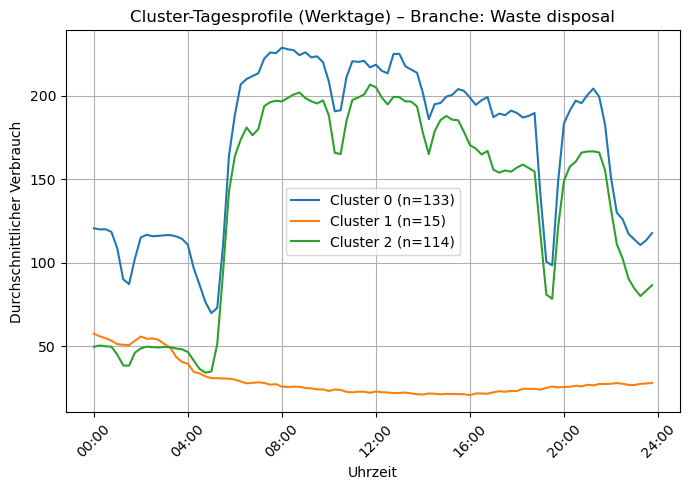

In [20]:
time_slots = daily_matrix.columns[:-1]  # ohne cluster
x = [t.hour*60 + t.minute for t in time_slots]

plt.figure(figsize=(7,5))

for c in range(k):
    mean_profile = daily_matrix[daily_matrix["cluster"] == c].iloc[:, :-1].mean()
    plt.plot(x, mean_profile.values, label=f"Cluster {c} (n={(clusters==c).sum()})")

ticks = list(range(0, 24*60+1, 240))
labels = [f"{m//60:02d}:00" for m in ticks]
plt.xticks(ticks, labels, rotation=45)

plt.title(f"Cluster-Tagesprofile (Werktage) – Branche: {industry}")
plt.xlabel("Uhrzeit")
plt.ylabel("Durchschnittlicher Verbrauch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
